In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *

%load_ext autoreload
%autoreload 2

/home/wd/repo/spont_approx/wave_approx.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
rLTD = 1.0
r0 = 6
rx = 20
l = 8
d = 3
v = 3.2
k = 0.114*0.017
A = 0.025
tau_m = 0.02
tau = 1
gL = 40
nT = 10
nt = 8000
w0 = 0.3
cap = 12
theme = 'gLs'

T = 5.411, dt = 6.763e-04, each LGN activated for 34.7%
max weight possible: 3.600e+00
using method exact1
10/10...T = 8.946, dt = 1.118e-03, each LGN activated for 21.0%
max weight possible: 3.600e+00
using method exact1
10/10...T = 16.017, dt = 2.002e-03, each LGN activated for 11.7%
max weight possible: 3.600e+00
using method exact1
10/10...

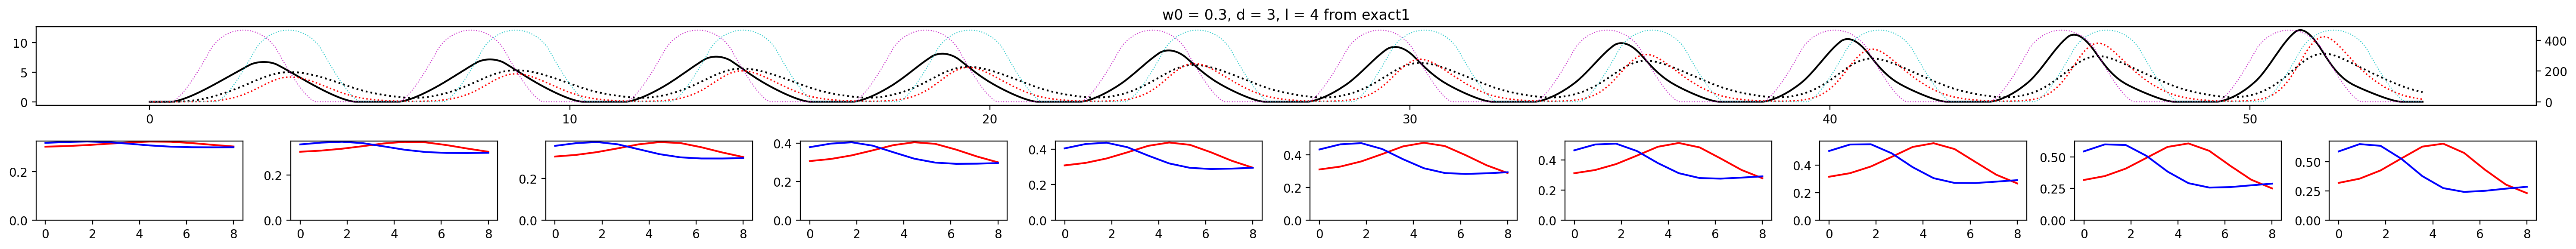

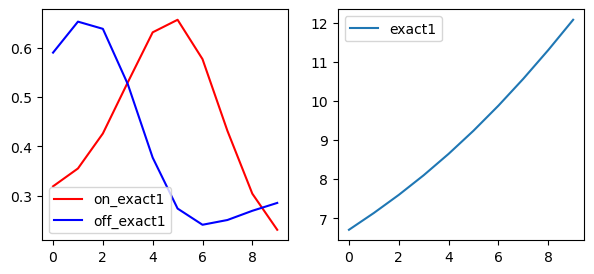

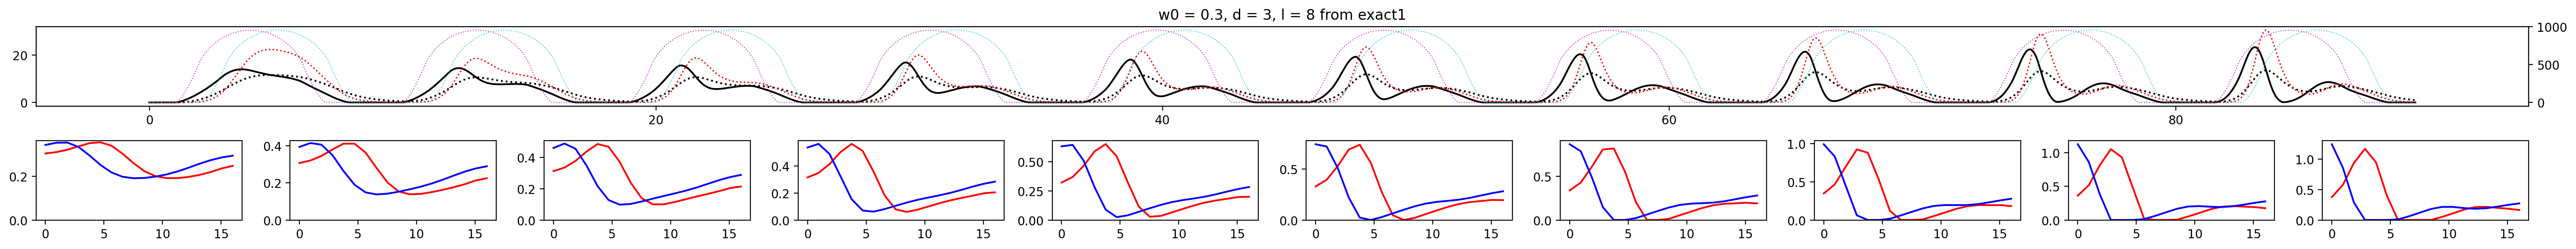

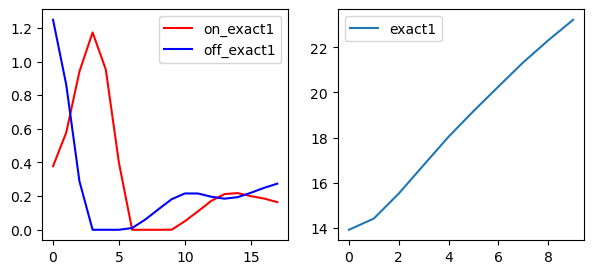

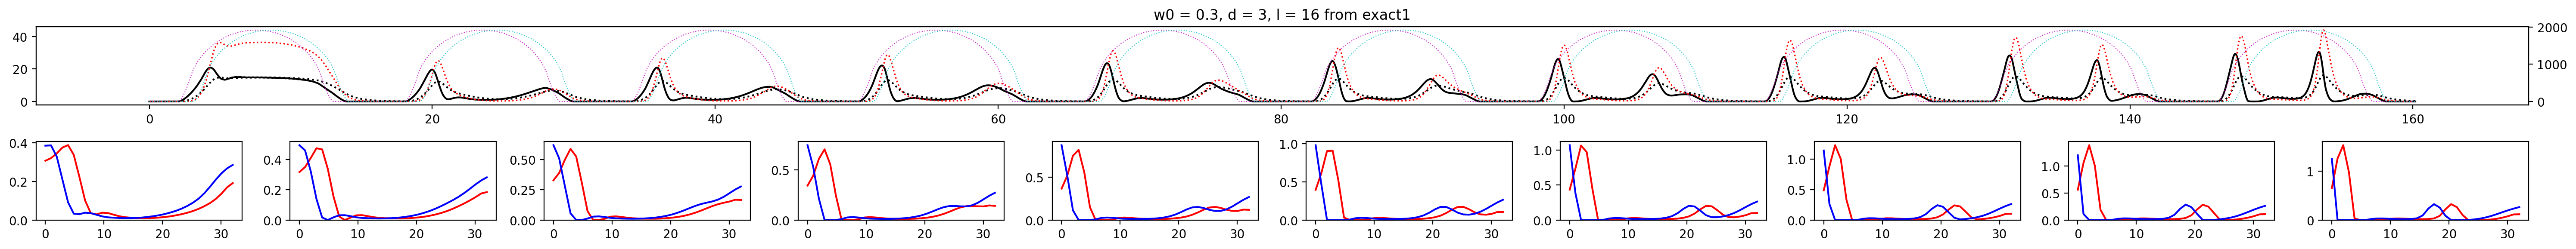

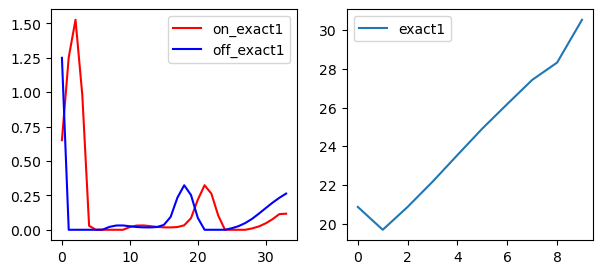

In [5]:
#gL_range = [10, 20, 40]
l_range = [4, 8, 16]
i = 0
fork_ivp = True 
#dT = 3
#_nt = nt*100
#for gL in gL_range:
for l in l_range:
    wt1_on, wt1_off, fr1, rbar1 = iter_sweep_III('exact1', nT = nT, w0 = w0, l = l, d = d, v = v, k = k, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nt = nt, plot = True, theme = f'{theme}_{i}', fork_ivp = fork_ivp)
    #wt0, fr0, rbar0 = iter_sweep('exact0', nT = nT, w0 = w0, l = l, d = d, v = v, k = k, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nt = nt, plot = True, theme = f'{theme}_{i}', fork_ivp = fork_ivp)
    #wt2, fr2, rbar2 = iter_sweep('approx2', nT = dT*nT, w0 = w0, l = l, d = d, v = v, k = k, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nt = _nt, plot = True, theme = f'{theme}_{i}', fork_ivp = fork_ivp)
    i += 1
    fig, ax = plt.subplots(1, 2, figsize = (7,3))
    nx = wt1_on.shape[0]
    #ax[0].plot(np.arange(nx), wt0[:,-1], label = 'exact0')
    ax[0].plot(np.arange(nx), wt1_on[:,-1], 'r', label = 'on_exact1')
    ax[0].plot(np.arange(nx), wt1_off[:,-1], 'b', label = 'off_exact1')
    #ax[0].plot(np.arange(nx), wt2[:,-1], ':', label = 'approx2')
    ax[0].legend()
    #ax[1].plot(np.arange(nT), [np.max(fr0[i*nt+1:(i+1)*nt+1]) for i in range(nT)], label = 'exact0')
    ax[1].plot(np.arange(nT), [np.max(fr1[i*nt+1:(i+1)*nt+1]) for i in range(nT)], label = 'exact1')
    #ax[1].plot(np.linspace(0, nT-1, nT*dT), [np.max(fr2[i*_nt+1:(i+1)*_nt+1]) for i in range(dT*nT)], ':', label = 'approx2')
    ax[1].legend()

T = 8.946, dt = 1.118e-03, each LGN activated for 21.0%
max weight possible: 3.600e+00
using method approx2
10/10...

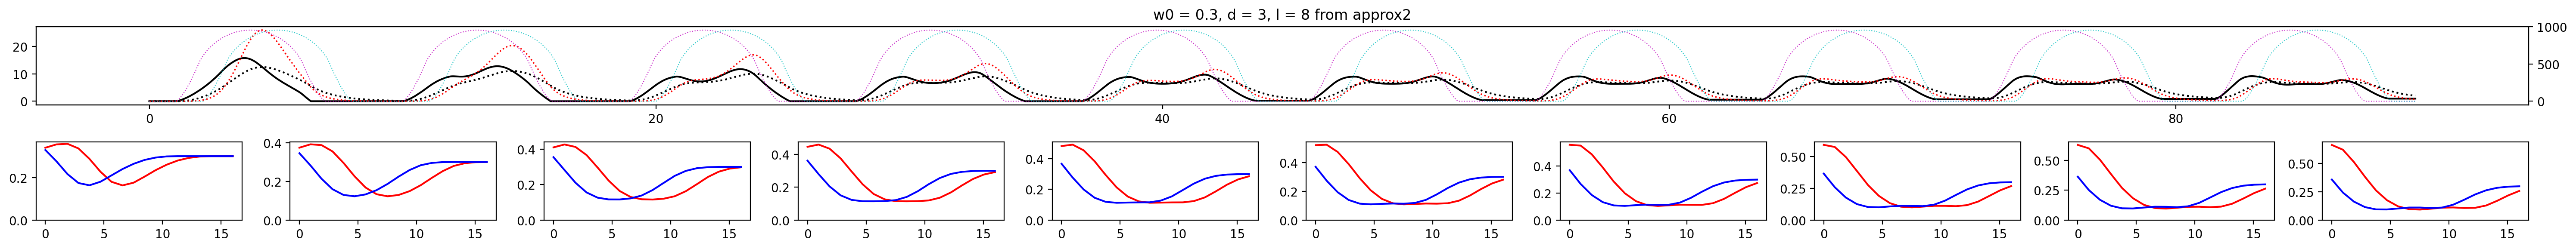

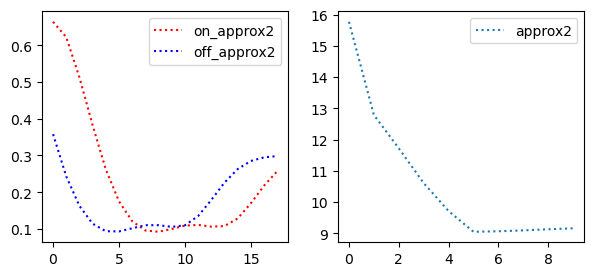

In [3]:
theme = 'for_phase'
fork_ivp = True
dT = 1
nT = 10
_nt = nt
wt2_on, wt2_off, fr2, rbar2 = iter_sweep_III('approx2', nT = dT*nT, w0 = w0, l = l, d = d, v = v, k = k, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nt = _nt, plot = True, theme = f'{theme}', fork_ivp = fork_ivp)
fig, ax = plt.subplots(1, 2, figsize = (7,3))
nx = wt2_on.shape[0]
ax[0].plot(np.arange(nx), wt2_on[:,-1], ':r', label = 'on_approx2')
ax[0].plot(np.arange(nx), wt2_off[:,-1], ':b', label = 'off_approx2')
ax[0].legend()
ax[1].plot(np.linspace(0, nT-1, nT*dT), [np.max(fr2[i*_nt+1:(i+1)*_nt+1]) for i in range(dT*nT)], ':', label = 'approx2')
ax[1].legend()

[0 0]
k = 4.845e-05, coef_0 = 1.938e-02


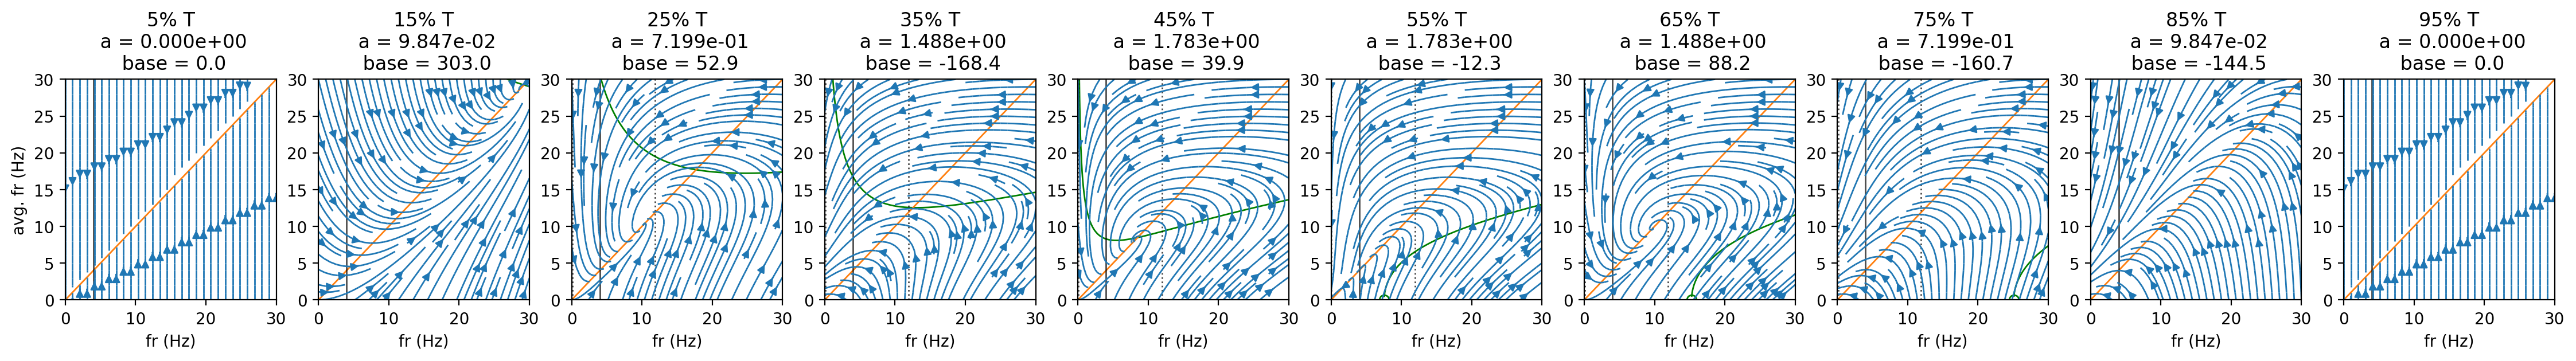

In [7]:
y2 = np.array([0, 0])
print(y2)
w = np.hstack((wt2_on[:,-1], wt2_off[:,-1]))
#w = np.zeros(wt2.shape[0]) + w0
L = 2*l*np.sqrt(2) + 2*d
T = L/v
dt = 1e-5
nt = int(T/dt)+2
t = np.arange(nt)*dt
n = 10
p = np.linspace(0.05,0.95,n)
r = np.linspace(0, 30, 30)
rbar = np.linspace(0, 30, 30)
# solve approx2, plot trace
fig = plt.figure(figsize = (14/5*n,2.5), dpi = 200)
# phase plane
k_prime = k*A
a = k_prime*rx*rx*int_circle_chord(T*p, v=v, d=d, l=l)
nx = 2*l+2
x = np.linspace(0, 2*l, nx)
print(f'k = {k_prime:.3e}, coef_0 = {k_prime*rx*rx:.3e}')
for i in range(n):
    ax = fig.add_subplot(1,n,i+1)
    phase_plane(get_dF2_III(wt2_on[:,-1], wt2_off[:,-1], False, half_circle_height, iint_circle_chord, T*p[i], k = k_prime, r0 = r0, l = l, d = d, v = v, rx = rx, tau = tau, gL = gL), r, rbar, ax = ax)
    _r = np.linspace(0,r[-1], 1000)
    _rbar, ro = nullcline2_III(_r, wt2_on[:,-1], wt2_off[:,-1], True, half_circle_height, iint_circle_chord, T*p[i], k_prime, l, d, v, r0, rx, gL)
    ax.plot(_r, _rbar, 'g', lw = 1, alpha = 1, zorder = 0)
    if ro is not None:
        ax.plot(ro, 0, 'og', fillstyle = 'none', alpha = 1, zorder = 0)
    ax.plot(_r, _r, lw = 1, alpha = 1, zorder = 0)
    ax.plot(2/3*r0+np.zeros_like(rbar), rbar, 'k', lw = 1, alpha = 0.7, zorder = 0)
    if a[i] > 1/r0:
        ax.plot(r0 + np.sqrt(r0*r0-1/a[i]) + np.zeros_like(rbar), rbar, ':k', lw = 1, alpha = 0.7, zorder = 0)
        ax.plot(r0 - np.sqrt(r0*r0-1/a[i]) + np.zeros_like(rbar), rbar, ':k', lw = 1, alpha = 0.7, zorder = 0)
    x_bot, x_top = get_xrange(T*p[i],v,d,l,1)
    Q_on = np.interp(x_top, x, wt2_on[:,-1]*half_circle_height(x_top, l) - np.interp(x_bot, x, wt2_on[:,-1])*half_circle_height(x_bot, l))
    x_bot, x_top = get_xrange(T*p[i]-d/v,v,d,l,1)
    Q_off = np.interp(x_top, x, wt2_off[:,-1]*half_circle_height(x_top, l) - np.interp(x_bot, x, wt2_off[:,-1])*half_circle_height(x_bot, l))
    ax.set_title(f'{p[i]*100:.0f}% T\n a = {a[i]:.3e}\n base = {2*v*rx*(Q_on + Q_off):.1f}')
    ax.set_xlim(r[0], r[-1])
    ax.set_ylim(rbar[0], rbar[-1])
    if i == 0:
        ax.set_ylabel('avg. fr (Hz)')
    ax.set_xlabel('fr (Hz)')